# Milestone 2

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
image_path = r"C:\Users\DELL\Desktop\MediScan\data\raw\diabetic-retinopathy-224x224-gaussian-filtered\Mild\0a61bddab956.png"
image = cv2.imread(image_path)

In [3]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

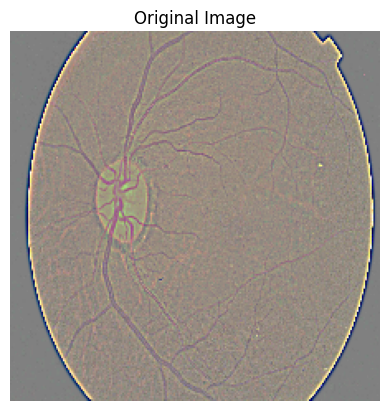

In [4]:
plt.imshow(image_rgb)
plt.title('Original Image')
plt.axis('off')
plt.savefig('original_image.png', bbox_inches='tight', pad_inches=0)
plt.show()

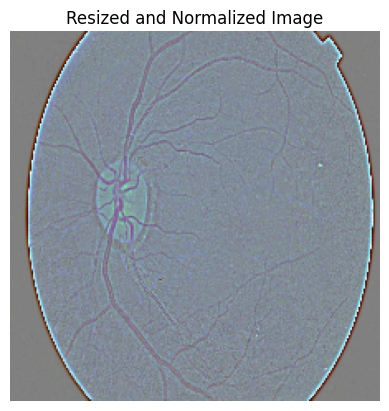

In [5]:
resized_image = cv2.resize(image, (224, 224))
normalized_image = resized_image / 255.0

plt.imshow(normalized_image)
plt.title('Resized and Normalized Image')
plt.axis('off')
plt.show()

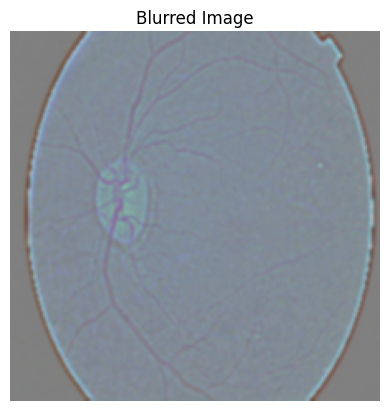

In [6]:
blurred_image = cv2.GaussianBlur(normalized_image, (5, 5), 0)

plt.imshow(blurred_image)
plt.title('Blurred Image')
plt.axis('off')
plt.show()

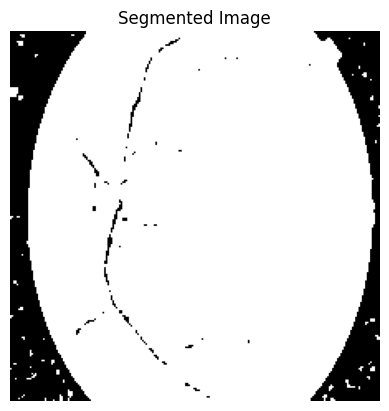

In [7]:
gray_image = cv2.cvtColor((blurred_image * 255).astype('uint8'), cv2.COLOR_RGB2GRAY)

_, segmented_image = cv2.threshold(gray_image, 128, 255, cv2.THRESH_BINARY)

plt.imshow(segmented_image, cmap='gray')
plt.title('Segmented Image')
plt.axis('off')
plt.savefig('segmented_image.png', bbox_inches='tight', pad_inches=0)
plt.show()

In [8]:
def preprocess_and_segment(image_path, model) :
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    resized_image = cv2. resize(image_rgb, (224, 224))
    normalized_image = resized_image / 255.0
    input_image = np.expand_dims(normalized_image, axis=0)
    segmentation_mask = model.predict(input_image)[0]
    segmentation_mask = (segmentation_mask > 0.5). astype(np.uint8)
    return resized_image, segmentation_mask

# MileStone 3

In [9]:
from skimage.feature.texture import graycomatrix, graycoprops
image = cv2.imread('segmented_image.png', 0)

In [10]:
glcm = graycomatrix(image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

In [11]:
contrast = graycoprops(glcm, 'contrast')[0, 0]
dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
energy = graycoprops(glcm, 'energy')[0, 0]
correlation = graycoprops(glcm, 'correlation')[0, 0]

In [12]:
print(f"Texture Features: Contrast: {contrast}, Dissimilarity: {dissimilarity}, Homogeneity: {homogeneity}, Energy: {energy}, Correlation: {correlation}")

Texture Features: Contrast: 548.0616590681641, Dissimilarity: 3.915045035027244, Homogeneity: 0.9543294224272261, Energy: 0.8255563751645294, Correlation: 0.9674587025490244


In [13]:
contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    largest_contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest_contour)
    perimeter = cv2.arcLength(largest_contour, True)
    
    print(f"Shape Features: Area: {area}, Perimeter: {perimeter}")

Shape Features: Area: 121730.5, Perimeter: 1700.8010770082474


In [14]:
colored_image = cv2.imread('original_image.png')

In [15]:
masked_image = cv2.bitwise_and(colored_image, colored_image, mask=image)
hist_b = cv2.calcHist([masked_image], [0], image, [256], [0, 256])
hist_g = cv2.calcHist([masked_image], [1], image, [256], [0, 256])
hist_r = cv2.calcHist([masked_image], [2], image, [256], [0, 256])

print(f"Color Histogram Features: Blue Channel Histogram: {hist_b.flatten()[:5]}")
print(f"Color Histogram Features: Green Channel Histogram: {hist_g.flatten()[:5]}")
print(f"Color Histogram Features: Red Channel Histogram: {hist_r.flatten()[:5]}")

Color Histogram Features: Blue Channel Histogram: [119.   4.   3.   2.   0.]
Color Histogram Features: Green Channel Histogram: [119.   5.   9.   5.   5.]
Color Histogram Features: Red Channel Histogram: [122.   9.  18.   4.   2.]


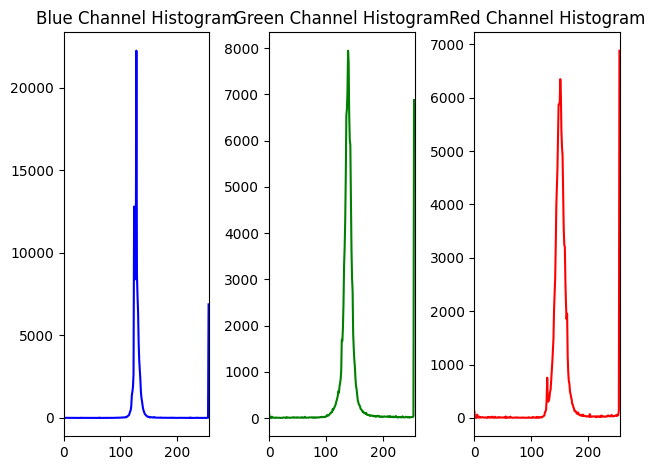

In [16]:
# Plot Blue Channel
plt.subplot(1, 3, 1)
plt.plot(hist_b, color='blue')
plt.title('Blue Channel Histogram')
plt.xlim([0, 256])
# Plot Green Channel
plt.subplot(1, 3, 2)
plt.plot(hist_g, color='green')
plt.title('Green Channel Histogram')
plt.xlim([0, 256])
# Plot Red Channel
plt.subplot(1, 3, 3)
plt.plot(hist_r, color='red')
plt.title('Red Channel Histogram')
plt.xlim([0, 256])
# Show the plot
plt.tight_layout()
plt.show()

In [30]:
from pathlib import Path
from sklearn.model_selection import train_test_split
from IPython.display import display, Markdown
from sklearn.metrics import confusion_matrix

def printmd(string):
    # Print with Markdown
    display(Markdown(string))

# Set your dataset directory
image_dir = Path(r"C:\Users\DELL\Desktop\MediScan\data\raw\diabetic-retinopathy-224x224-gaussian-filtered")

# Get filepaths and labels
filepaths = list(image_dir.glob(r'**/*.png'))  # Recursive glob for .png files
labels = [path.parent.name for path in filepaths]  # Extract folder names as labels

# Create Pandas Series for filepaths and labels
filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')

# Concatenate filepaths and labels into a DataFrame
image_df = pd.concat([filepaths, labels], axis=1)

# Shuffle the DataFrame and reset the index
image_df = image_df.sample(frac=1).reset_index(drop=True)

# Display the first few rows of the DataFrame
print(image_df.head())

                                            Filepath           Label
0  C:\Users\DELL\Desktop\MediScan\data\raw\diabet...  Proliferate_DR
1  C:\Users\DELL\Desktop\MediScan\data\raw\diabet...        Moderate
2  C:\Users\DELL\Desktop\MediScan\data\raw\diabet...        Moderate
3  C:\Users\DELL\Desktop\MediScan\data\raw\diabet...        Moderate
4  C:\Users\DELL\Desktop\MediScan\data\raw\diabet...        Moderate


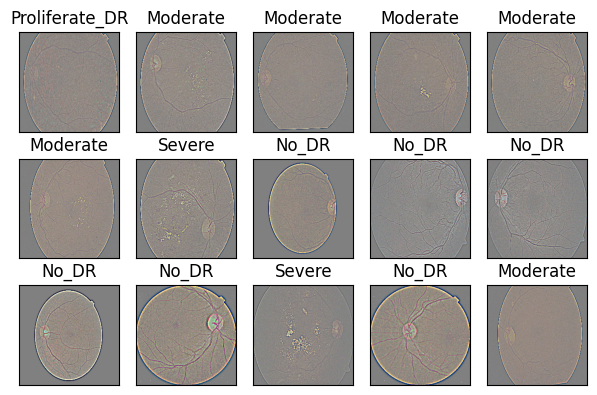

In [35]:
# Create a subplot grid
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(6, 4),
                        subplot_kw={'xticks': [], 'yticks': []})

# Loop through each subplot and display images
for i, ax in enumerate(axes.flat):
    image = cv2.imread(image_df.Filepath[i])  # Load image using OpenCV
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert color from BGR to RGB
    ax.imshow(image_rgb)  # Display the image
    ax.set_title(image_df.Label[i])  # Set the label as the title

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


C:\Users\DELL\AppData\Local\Temp\ipykernel_64668\3020583472.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = vc.index, y = vc, palette = "pastel")


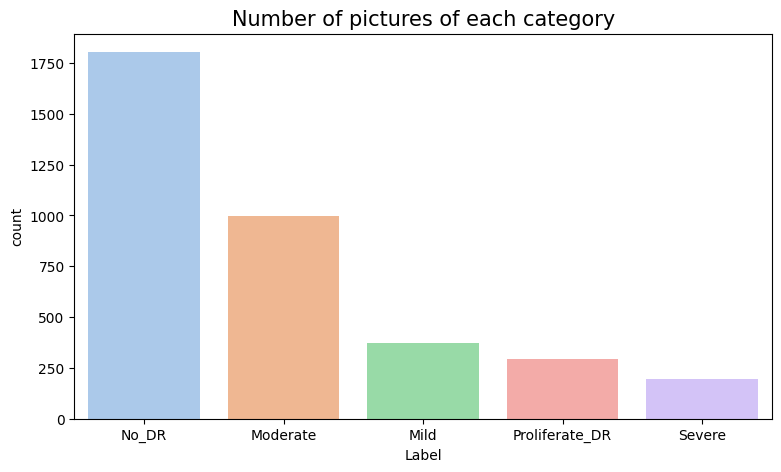

In [19]:
# Count the number of images in each category
vc = image_df['Label'].value_counts()
# Create a bar plot to visualize the distribution of categories
plt.figure(figsize=(9,5))
sns.barplot(x = vc.index, y = vc, palette = "pastel")
# Add title and display the plot
plt.title("Number of pictures of each category", fontsize = 15)
plt.show()

In [27]:
def create_gen():
    # Load the Images with a generator and Data Augmentation
    train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
        validation_split=0.1
    )

    test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
        preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
    )

    train_images = train_generator.flow_from_dataframe(
        dataframe=train_df,
        x_col='Filepath',
        y_col='Label',
        target_size=(224, 224),
        color_mode='rgb',
        class_mode='categorical',
        batch_size=32,
        shuffle=True,
        seed=0,
        subset='training',
        rotation_range=30, # Uncomment to use data augmentation
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        horizontal_flip=True,
        fill_mode="nearest"
    )

    val_images = train_generator.flow_from_dataframe(
        dataframe=train_df,
        x_col='Filepath',
        y_col='Label',
        target_size=(224, 224),
        color_mode='rgb',
        class_mode='categorical',
        batch_size=32,
        shuffle=True,
        seed=0,
        subset='validation',
        rotation_range=30, # Uncomment to use data augmentation
        zoom_range=0.15,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.15,
        horizontal_flip=True,
        fill_mode="nearest"
    )

    test_images = test_generator.flow_from_dataframe(
        dataframe=test_df,
        x_col='Filepath',
        y_col='Label',
        target_size=(224, 224),
        color_mode='rgb',
        class_mode='categorical',
        batch_size=32,
        shuffle=False
    )
    
    return train_generator,test_generator,train_images,val_images,test_images

In [21]:
# Map the labels to have only "No_DR" and "DR"
image_df_red = image_df.copy()
image_df_red['Label'] = image_df_red['Label'].apply(lambda x: x if x == 'No_DR' else 'DR')
image_df_red.head()

,Filepath,Label
0,C:\Users\DELL\Desktop\MediScan\data\raw\diabet...,No_DR
1,C:\Users\DELL\Desktop\MediScan\data\raw\diabet...,No_DR
2,C:\Users\DELL\Desktop\MediScan\data\raw\diabet...,DR
3,C:\Users\DELL\Desktop\MediScan\data\raw\diabet...,No_DR
4,C:\Users\DELL\Desktop\MediScan\data\raw\diabet...,No_DR


C:\Users\DELL\AppData\Local\Temp\ipykernel_64668\1232219850.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = vc.index, y = vc, palette = "pastel")


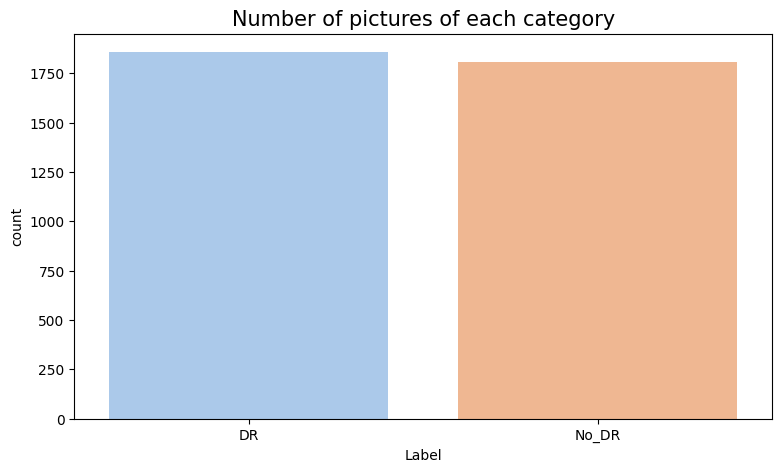

In [22]:
# Display the number of pictures of each category
vc = image_df_red['Label'].value_counts()
plt.figure(figsize=(9,5))
sns.barplot(x = vc.index, y = vc, palette = "pastel")
plt.title("Number of pictures of each category", fontsize = 15)
plt.show()

In [23]:
# Separate in train and test data
train_df, test_df = train_test_split(image_df_red, train_size=0.9, shuffle=True, random_state=1)

In [28]:
# Create the generators
train_generator,test_generator,train_images,val_images,test_images=create_gen()

# Load the pretained model
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

pretrained_model.trainable = False


inputs = pretrained_model.input

x = tf.keras.layers.Dense(128, activation='relu')(pretrained_model.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)

outputs = tf.keras.layers.Dense(2, activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_images,
    validation_data=val_images,
    batch_size = 32,
    epochs=10,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]
)

Found 2966 validated image filenames belonging to 2 classes.
Found 329 validated image filenames belonging to 2 classes.
Found 367 validated image filenames belonging to 2 classes.
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


c:\Users\DELL\Desktop\MediScan\mediscan_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 90s 902ms/step - accuracy: 0.9040 - loss: 0.2435 - val_accuracy: 0.9331 - val_loss: 0.1888
Epoch 2/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 59s 638ms/step - accuracy: 0.9569 - loss: 0.1431 - val_accuracy: 0.9392 - val_loss: 0.1683
Epoch 3/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 81s 874ms/step - accuracy: 0.9639 - loss: 0.1106 - val_accuracy: 0.9514 - val_loss: 0.1569
Epoch 4/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 60s 648ms/step - accuracy: 0.9644 - loss: 0.1002 - val_accuracy: 0.9483 - val_loss: 0.1745
Epoch 5/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 47s 501ms/step - accuracy: 0.9717 - loss: 0.0817 - val_accuracy: 0.9179 - val_loss: 0.2086
Epoch 6/10
93/93 ━━━━━━━━━━━━━━━━━━━━ 34s 360ms/step - accuracy: 0.9783 - loss: 0.0725 - val_accuracy: 0.9422 - val_loss: 0.1853


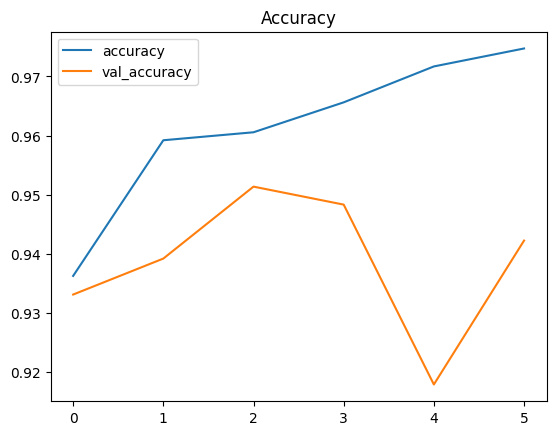

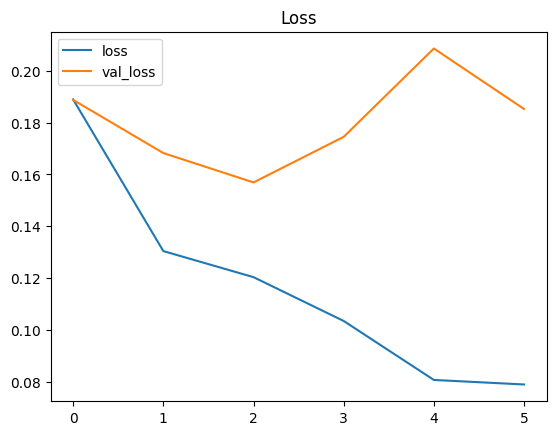

 ## Test Loss: 0.14856

## Accuracy on the test set: 95.37%



12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 334ms/step
The first 5 predictions: ['No_DR', 'No_DR', 'DR', 'DR', 'No_DR']
              precision    recall  f1-score   support

          DR       0.95      0.95      0.95       165
       No_DR       0.96      0.96      0.96       202

    accuracy                           0.95       367
   macro avg       0.95      0.95      0.95       367
weighted avg       0.95      0.95      0.95       367



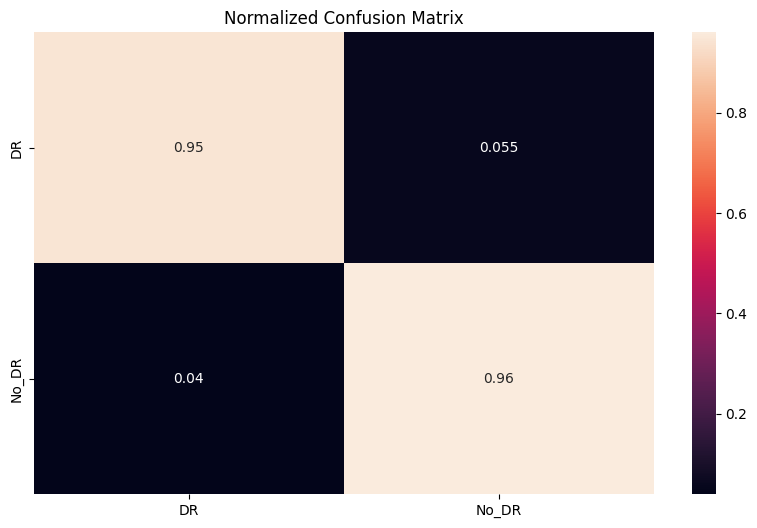

In [31]:
pd.DataFrame(history.history)[['accuracy','val_accuracy']].plot()
plt.title("Accuracy")
plt.show()

pd.DataFrame(history.history)[['loss','val_loss']].plot()
plt.title("Loss")
plt.show()

results = model.evaluate(test_images, verbose=0)

printmd(" ## Test Loss: {:.5f}".format(results[0]))
printmd("## Accuracy on the test set: {:.2f}%".format(results[1] * 100))
print('\n')

# Predict the label of the test_images
pred = model.predict(test_images)
pred = np.argmax(pred,axis=1)

# Map the label
labels = (train_images.class_indices)
labels = dict((v,k) for k,v in labels.items())
pred = [labels[k] for k in pred]

# Display the result
print(f'The first 5 predictions: {pred[:5]}')

from sklearn.metrics import classification_report
y_test = list(test_df.Label)
print(classification_report(y_test, pred))

cf_matrix = confusion_matrix(y_test, pred, normalize='true')
plt.figure(figsize = (10,6))
sns.heatmap(cf_matrix, annot=True, xticklabels = sorted(set(y_test)), yticklabels = sorted(set(y_test)))
plt.title('Normalized Confusion Matrix')
plt.show()

In [33]:
model.save('diabetic_retinopathy_model.h5')

In [34]:
model.save('diabetic_retinopathy_model.keras')